# 01 — Eksplorasi Data Awal (EDA)

**Skripsi:** Implementasi *Time Series Foundation Model* Chronos-2 untuk Peramalan Probabilistik Harga Perak dengan Variabel Kovariat Harga Emas dan Dollar Index

Notebook ini mendeskripsikan karakteristik data yang sudah melewati penyelarasan tanggal antar-bursa dan pembagian kronologis latih/validasi/uji.

**Ruang lingkup dan batasannya:**

- Notebook hanya *mengimpor* dari `src/`. Tidak ada fungsi pipeline, metrik evaluasi, maupun logika pembagian data yang didefinisikan ulang di sini. Batas tanggal tiap split dibaca dari `results/metrics/data_quality_report.json`, bukan dihitung ulang.
- Uji stasioneritas (bagian 6) dihitung **hanya pada data latih**, karena hasilnya menjadi dasar pemilihan transformasi pada analisis *Mutual Information* (Notebook 02). Statistik yang menjadi dasar keputusan metodologis tidak boleh bersumber dari data validasi maupun data uji — inilah prinsip dasar pencegahan kebocoran informasi (*data leakage*) pada peramalan deret waktu. Statistik deskriptif dan plot pada bagian 2–4 bersifat pelaporan sehingga memakai seluruh periode.
- Notebook ini **tidak** menjalankan prediksi apa pun pada data uji.

In [1]:
import json
import sys
from pathlib import Path

# Tambahkan akar project ke sys.path agar `import src.*` bekerja dari folder notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import jarque_bera
from statsmodels.tsa.stattools import adfuller, kpss

from src.preprocessing import get_covariate_columns, get_target_column
from src.utils import load_config, resolve_path

%matplotlib inline

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["savefig.bbox"] = "tight"
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

CONFIG = load_config()
TARGET_COL = get_target_column(CONFIG)
COVARIATE_COLS = get_covariate_columns(CONFIG)
PRICE_COLS = [TARGET_COL, *COVARIATE_COLS]

# Parameter khusus eksplorasi (hanya berlaku di notebook, bukan parameter pipeline)
VOLATILITY_WINDOW = 30       # hari perdagangan
TRADING_DAYS_PER_YEAR = 252  # penyetahunan volatilitas
ALPHA = 0.05                 # taraf nyata uji statistik

FIGURES_DIR = resolve_path(CONFIG["paths"]["figures_dir"])
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Label yang enak dibaca untuk keperluan plot dan tabel
LABELS = {
    spec["column"]: name.upper() for name, spec in CONFIG["data"]["tickers"].items()
}
TICKERS = {spec["column"]: spec["ticker"] for spec in CONFIG["data"]["tickers"].values()}

print("Target    :", TARGET_COL, f"({TICKERS[TARGET_COL]})")
print("Kovariat  :", COVARIATE_COLS)
print("Figures   :", FIGURES_DIR)

Target    : silver_close (SI=F)
Kovariat  : ['gold_close', 'dxy_close']
Figures   : D:\project-skripsi\results\figures


## 1. Memuat data hasil preprocessing

Sumber: `data/processed/aligned.csv` (hasil penyelarasan tanggal) dan `results/metrics/data_quality_report.json` (laporan kualitas + batas split).

In [2]:
aligned_path = resolve_path(CONFIG["data"]["processed_dir"]) / "aligned.csv"
report_path = resolve_path(CONFIG["paths"]["metrics_dir"]) / "data_quality_report.json"

df = pd.read_csv(aligned_path, index_col="date", parse_dates=["date"])
with report_path.open("r", encoding="utf-8") as file:
    report = json.load(file)

# Batas tiap split dibaca dari laporan, TIDAK dihitung ulang di notebook
SPLIT_INFO = report["split"]["splits"]
SPLIT_BOUNDS = {
    name: (pd.Timestamp(info["date_start"]), pd.Timestamp(info["date_end"]))
    for name, info in SPLIT_INFO.items()
}

print(f"aligned.csv : {len(df)} baris x {df.shape[1]} kolom")
print(f"Periode     : {df.index[0].date()} s/d {df.index[-1].date()}")
print(f"Kolom       : {list(df.columns)}")
print(f"NaN tersisa : {int(df.isna().sum().sum())}")
print()
for name, (start, end) in SPLIT_BOUNDS.items():
    n = SPLIT_INFO[name]["n_rows"]
    ratio = SPLIT_INFO[name]["ratio_actual"]
    print(f"{name:<6} {n:>5} baris ({ratio:6.2%})  {start.date()} s/d {end.date()}")

df.head()

aligned.csv : 1257 baris x 5 kolom
Periode     : 2021-08-16 s/d 2026-08-14
Kolom       : ['silver_close', 'gold_close', 'dxy_close', 'gold_ffilled', 'dxy_ffilled']
NaN tersisa : 0

train    879 baris (69.93%)  2021-08-16 s/d 2025-02-12
val      188 baris (14.96%)  2025-02-13 s/d 2025-11-10
test     190 baris (15.12%)  2025-11-11 s/d 2026-08-14


,silver_close,gold_close,dxy_close,gold_ffilled,dxy_ffilled
date,,,,,
2021-08-16,23.7800,"1,786.9000",92.6300,False,False
2021-08-17,23.6480,"1,785.0000",93.1300,False,False
2021-08-18,23.4120,"1,781.6000",93.1400,False,False
2021-08-19,23.2200,"1,780.2000",93.5700,False,False
2021-08-20,23.1050,"1,781.0000",93.5000,False,False


In [3]:
# Potongan data latih dipakai khusus untuk uji stasioneritas (agar tanpa kebocoran)
train_start, train_end = SPLIT_BOUNDS["train"]
df_train = df.loc[train_start:train_end]

print(f"Data latih untuk uji statistik: {len(df_train)} baris "
      f"({df_train.index[0].date()} s/d {df_train.index[-1].date()})")

Data latih untuk uji statistik: 879 baris (2021-08-16 s/d 2025-02-12)


## 2. Statistik deskriptif

Catatan: `kurtosis` yang dilaporkan pandas adalah **excess kurtosis** (Fisher), sehingga distribusi normal bernilai 0, bukan 3.

In [4]:
descriptive = pd.DataFrame(
    {
        "ticker": pd.Series({c: TICKERS[c] for c in PRICE_COLS}),
        "n": df[PRICE_COLS].count(),
        "mean": df[PRICE_COLS].mean(),
        "std": df[PRICE_COLS].std(),
        "min": df[PRICE_COLS].min(),
        "q25": df[PRICE_COLS].quantile(0.25),
        "median": df[PRICE_COLS].median(),
        "q75": df[PRICE_COLS].quantile(0.75),
        "max": df[PRICE_COLS].max(),
        "skewness": df[PRICE_COLS].skew(),
        "kurtosis_excess": df[PRICE_COLS].kurtosis(),
        "cv": df[PRICE_COLS].std() / df[PRICE_COLS].mean(),
    }
)
descriptive.index.name = "kolom"
descriptive

,ticker,n,mean,std,min,q25,median,q75,max,skewness,kurtosis_excess,cv
kolom,,,,,,,,,,,,
silver_close,SI=F,1257,33.7001,17.8228,17.5510,22.9120,25.2930,34.0510,115.0800,1.8667,2.7122,0.5289
gold_close,GC=F,1257,"2,618.2939",986.3652,"1,623.3000","1,861.8000","2,047.1000","3,305.0000","5,318.3999",1.0723,-0.1340,0.3767
dxy_close,DX-Y.NYB,1257,101.9635,4.1905,92.0400,98.8200,102.2900,104.6700,114.1100,0.0513,-0.2159,0.0411


## 3. Plot ketiga seri harga

Tiga subplot bertumpuk dengan sumbu tanggal disamakan (`sharex=True`). Skala harga ketiganya sangat berbeda (Perak puluhan USD, Emas ribuan USD, DXY sekitar 100), sehingga tidak bisa disatukan dalam satu sumbu-y.

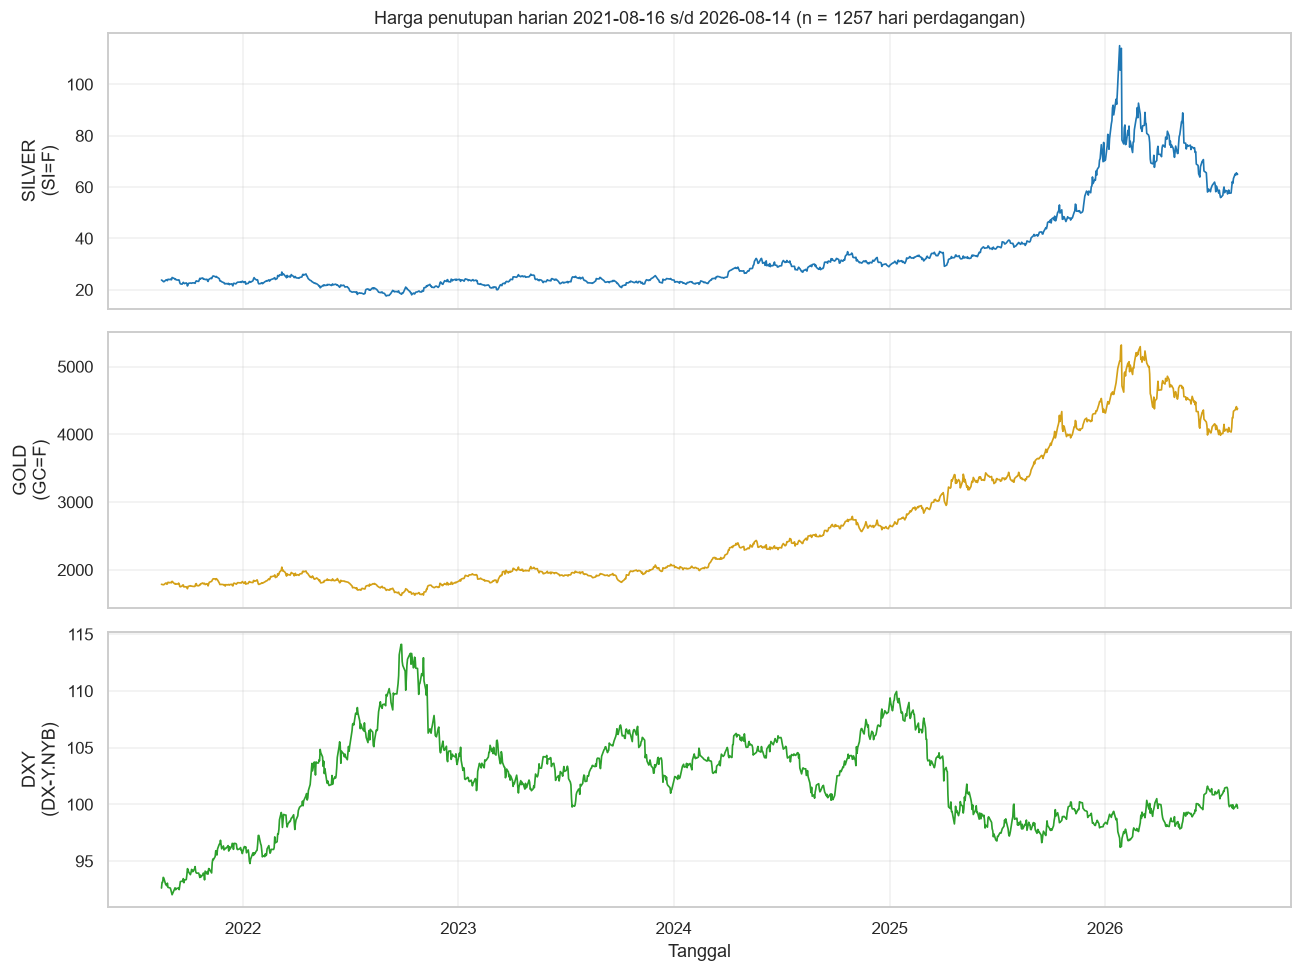

Tersimpan: D:\project-skripsi\results\figures\eda_series.png


In [5]:
PALETTE = {TARGET_COL: "#1f77b4", COVARIATE_COLS[0]: "#d4a017", COVARIATE_COLS[1]: "#2ca02c"}

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

for ax, column in zip(axes, PRICE_COLS):
    ax.plot(df.index, df[column], color=PALETTE[column], linewidth=1.1)
    ax.set_ylabel(f"{LABELS[column]}\n({TICKERS[column]})")
    ax.grid(True, alpha=0.3)

axes[0].set_title(
    f"Harga penutupan harian {df.index[0].date()} s/d {df.index[-1].date()} "
    f"(n = {len(df)} hari perdagangan)",
    fontsize=12,
)
axes[-1].set_xlabel("Tanggal")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_series.png")
plt.show()

print("Tersimpan:", FIGURES_DIR / "eda_series.png")

## 4. Perbandingan ternormalisasi (basis = 100)

Seluruh seri diskalakan ke 100 pada tanggal awal supaya pergerakan relatifnya bisa dibandingkan langsung. Garis vertikal putus-putus menandai batas latih/validasi/uji.

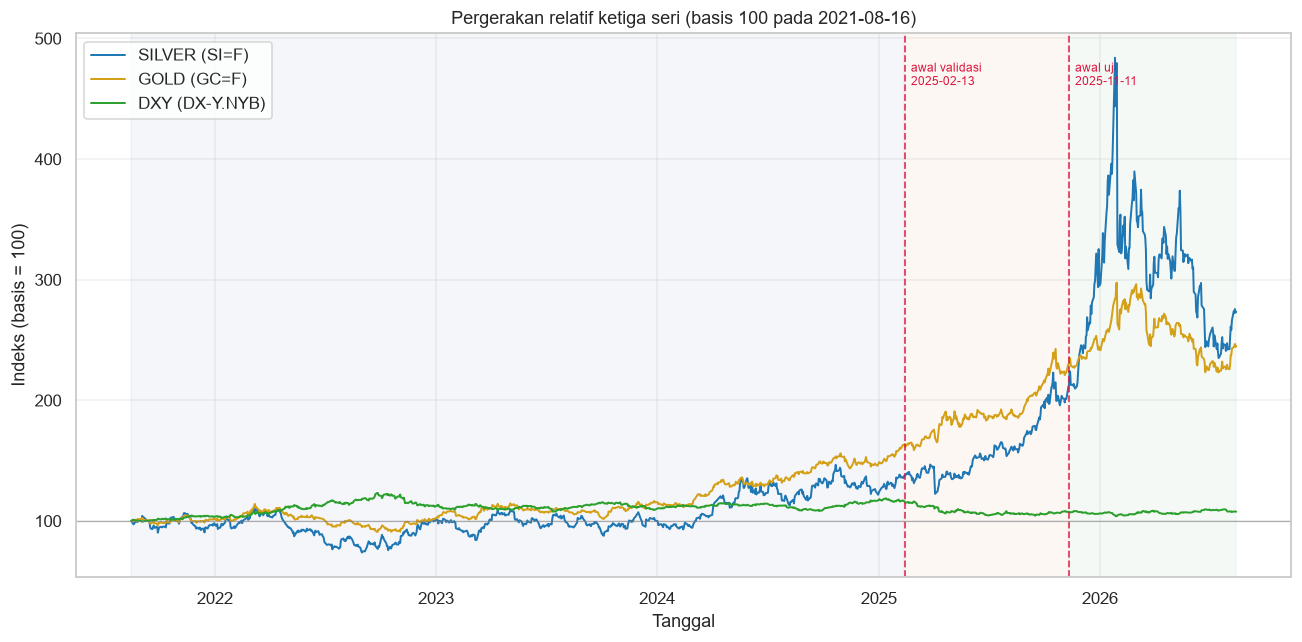

Nilai indeks pada akhir periode (basis 100 di awal):
  SILVER    273.29
  GOLD      245.14
  DXY       107.60

Tersimpan: D:\project-skripsi\results\figures\eda_normalized.png


In [6]:
normalized = df[PRICE_COLS].div(df[PRICE_COLS].iloc[0]).mul(100)

fig, ax = plt.subplots(figsize=(12, 6))

for column in PRICE_COLS:
    ax.plot(
        normalized.index,
        normalized[column],
        label=f"{LABELS[column]} ({TICKERS[column]})",
        color=PALETTE[column],
        linewidth=1.3,
    )

# Batas split: awal validasi dan awal uji
boundaries = {
    "awal validasi": SPLIT_BOUNDS["val"][0],
    "awal uji": SPLIT_BOUNDS["test"][0],
}
for label, boundary in boundaries.items():
    ax.axvline(boundary, color="crimson", linestyle="--", linewidth=1.2, alpha=0.8)
    ax.annotate(
        f"{label}\n{boundary.date()}",
        xy=(boundary, ax.get_ylim()[1]),
        xytext=(4, -34),
        textcoords="offset points",
        fontsize=8,
        color="crimson",
    )

# Arsiran latar untuk memperjelas ketiga periode
for name, color in (("train", "#4c72b0"), ("val", "#dd8452"), ("test", "#55a868")):
    start, end = SPLIT_BOUNDS[name]
    ax.axvspan(start, end, color=color, alpha=0.06)

ax.axhline(100, color="gray", linewidth=0.8, alpha=0.6)
ax.set_title(f"Pergerakan relatif ketiga seri (basis 100 pada {df.index[0].date()})")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Indeks (basis = 100)")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_normalized.png")
plt.show()

print("Nilai indeks pada akhir periode (basis 100 di awal):")
for column in PRICE_COLS:
    print(f"  {LABELS[column]:<7} {normalized[column].iloc[-1]:8.2f}")
print("\nTersimpan:", FIGURES_DIR / "eda_normalized.png")

## 5. Distribusi log-return dan uji normalitas Jarque-Bera

Log-return didefinisikan sebagai $r_t = \ln(P_t / P_{t-1})$.

Hipotesis Jarque-Bera: $H_0$ = data berdistribusi normal. Bila $p < 0{,}05$, $H_0$ ditolak.

In [7]:
log_returns = np.log(df[PRICE_COLS] / df[PRICE_COLS].shift(1)).dropna()

jb_rows = []
for column in PRICE_COLS:
    series = log_returns[column]
    result = jarque_bera(series.to_numpy())
    jb_rows.append(
        {
            "kolom": column,
            "n": int(series.size),
            "mean": series.mean(),
            "std": series.std(),
            "skewness": series.skew(),
            "kurtosis_excess": series.kurtosis(),
            "JB_statistic": float(result.statistic),
            "JB_pvalue": float(result.pvalue),
            "normal?": "ya" if result.pvalue > ALPHA else "TIDAK",
        }
    )

jb_table = pd.DataFrame(jb_rows).set_index("kolom")
jb_table

,n,mean,std,skewness,kurtosis_excess,JB_statistic,JB_pvalue,normal?
kolom,,,,,,,,
silver_close,1256,0.0008,0.0253,-2.6337,40.4198,"86,249.7686",0.0000,TIDAK
gold_close,1256,0.0007,0.0118,-1.1240,10.6601,"6,158.3410",0.0000,TIDAK
dxy_close,1256,0.0001,0.0045,-0.3628,1.6340,165.2933,0.0000,TIDAK


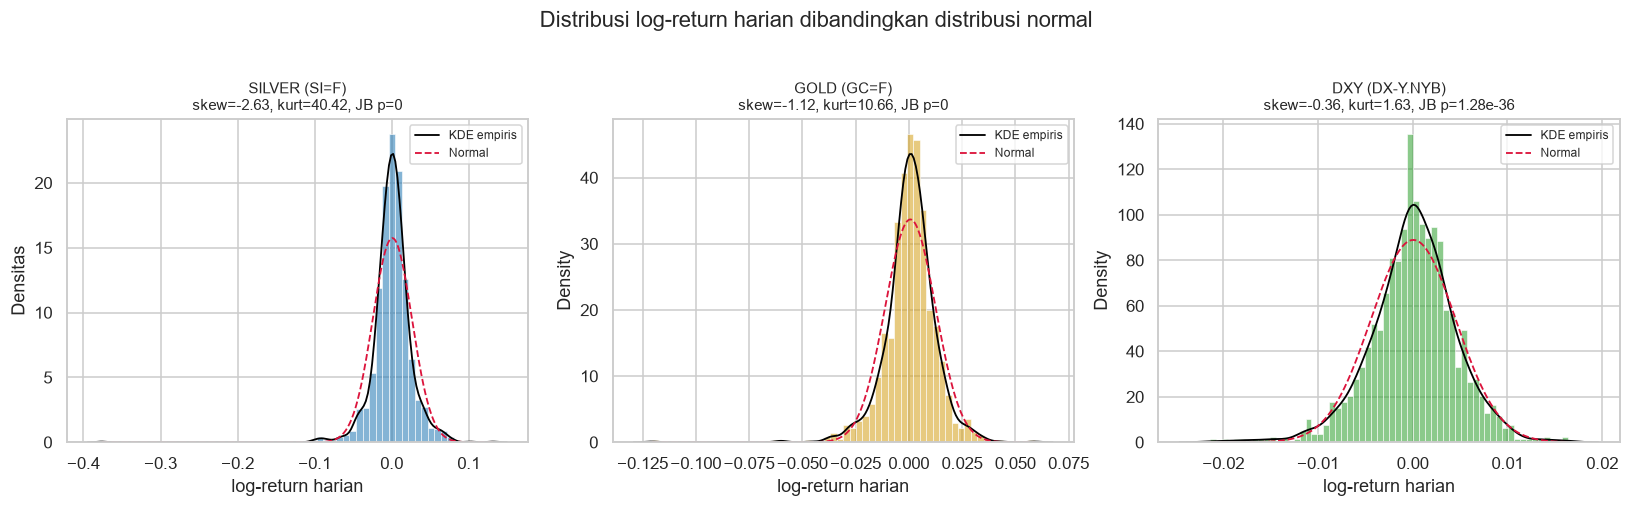

Tersimpan: D:\project-skripsi\results\figures\eda_returns_dist.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, column in zip(axes, PRICE_COLS):
    series = log_returns[column]
    sns.histplot(series, bins=60, stat="density", ax=ax, color=PALETTE[column], alpha=0.55)
    sns.kdeplot(series, ax=ax, color="black", linewidth=1.2, label="KDE empiris")

    # Kurva normal pembanding dengan mean & std yang sama
    grid = np.linspace(series.min(), series.max(), 400)
    normal_pdf = (
        1.0 / (series.std() * np.sqrt(2 * np.pi))
        * np.exp(-0.5 * ((grid - series.mean()) / series.std()) ** 2)
    )
    ax.plot(grid, normal_pdf, color="crimson", linestyle="--", linewidth=1.2, label="Normal")

    p_value = jb_table.loc[column, "JB_pvalue"]
    ax.set_title(
        f"{LABELS[column]} ({TICKERS[column]})\n"
        f"skew={series.skew():.2f}, kurt={series.kurtosis():.2f}, JB p={p_value:.3g}",
        fontsize=10,
    )
    ax.set_xlabel("log-return harian")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Densitas")
fig.suptitle("Distribusi log-return harian dibandingkan distribusi normal", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_returns_dist.png")
plt.show()

print("Tersimpan:", FIGURES_DIR / "eda_returns_dist.png")

## 6. Uji stasioneritas: ADF dan KPSS

**Dihitung hanya pada data latih**, karena hasilnya menjadi dasar pemilihan transformasi pada analisis *Mutual Information* (Notebook 02); statistik yang menjadi dasar keputusan metodologis tidak boleh mengambil informasi dari data validasi maupun data uji.

Kedua uji ini punya hipotesis nol yang berlawanan, sehingga saling melengkapi:

| Uji | $H_0$ | $H_1$ | Kesimpulan bila $p < 0{,}05$ |
|---|---|---|---|
| ADF | ada *unit root* (tidak stasioner) | stasioner | tolak $H_0$ → **stasioner** |
| KPSS | stasioner (di sekitar konstanta) | tidak stasioner | tolak $H_0$ → **tidak stasioner** |

Kesimpulan paling meyakinkan diperoleh bila keduanya sepakat.

In [9]:
import warnings


def run_stationarity_tests(series: pd.Series, label: str, transform: str) -> dict:
    """Menjalankan ADF dan KPSS pada satu deret, lalu merangkum kesimpulannya.

    Fungsi ini murni pelaporan EDA (bukan logika pipeline), sehingga boleh
    berada di notebook.
    """
    clean = series.dropna().to_numpy()

    adf_stat, adf_p, adf_lag, adf_nobs, adf_crit, _ = adfuller(clean, autolag="AIC")

    # KPSS memunculkan InterpolationWarning saat p-value berada di luar tabel;
    # itu wajar dan hanya berarti p-value terpotong pada batas tabel.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_stat, kpss_p, kpss_lag, kpss_crit = kpss(clean, regression="c", nlags="auto")

    adf_stationary = adf_p < ALPHA
    kpss_stationary = kpss_p > ALPHA

    if adf_stationary and kpss_stationary:
        conclusion = "stasioner (kedua uji sepakat)"
    elif not adf_stationary and not kpss_stationary:
        conclusion = "TIDAK stasioner (kedua uji sepakat)"
    elif adf_stationary and not kpss_stationary:
        conclusion = "tidak konklusif (indikasi tren deterministik)"
    else:
        conclusion = "tidak konklusif (indikasi beda-stasioner)"

    return {
        "seri": label,
        "transformasi": transform,
        "n": int(clean.size),
        "ADF_stat": adf_stat,
        "ADF_p": adf_p,
        "ADF_lag": int(adf_lag),
        "ADF_crit_5%": adf_crit["5%"],
        "KPSS_stat": kpss_stat,
        "KPSS_p": kpss_p,
        "KPSS_crit_5%": kpss_crit["5%"],
        "kesimpulan": conclusion,
    }


train_log_returns = np.log(df_train[PRICE_COLS] / df_train[PRICE_COLS].shift(1)).dropna()

stationarity_rows = []
for column in PRICE_COLS:
    stationarity_rows.append(
        run_stationarity_tests(df_train[column], LABELS[column], "level harga")
    )
for column in PRICE_COLS:
    stationarity_rows.append(
        run_stationarity_tests(train_log_returns[column], LABELS[column], "log-return")
    )

stationarity = pd.DataFrame(stationarity_rows)
stationarity

,seri,transformasi,n,ADF_stat,ADF_p,ADF_lag,ADF_crit_5%,KPSS_stat,KPSS_p,KPSS_crit_5%,kesimpulan
0,SILVER,level harga,879,-0.6919,0.8488,14,-2.8649,2.7823,0.0100,0.4630,TIDAK stasioner (kedua uji sepakat)
1,GOLD,level harga,879,1.0771,0.9950,4,-2.8649,3.6645,0.0100,0.4630,TIDAK stasioner (kedua uji sepakat)
2,DXY,level harga,879,-2.1571,0.2222,6,-2.8649,1.4920,0.0100,0.4630,TIDAK stasioner (kedua uji sepakat)
3,SILVER,log-return,878,-29.7313,0.0000,0,-2.8648,0.1010,0.1000,0.4630,stasioner (kedua uji sepakat)
4,GOLD,log-return,878,-11.6883,0.0000,4,-2.8649,0.2892,0.1000,0.4630,stasioner (kedua uji sepakat)
5,DXY,log-return,878,-23.2684,0.0000,1,-2.8648,0.1500,0.1000,0.4630,stasioner (kedua uji sepakat)


In [10]:
print("RINGKASAN STASIONERITAS (data latih)")
print("=" * 72)
for transform in ("level harga", "log-return"):
    print(f"\n{transform.upper()}")
    subset = stationarity[stationarity["transformasi"] == transform]
    for _, row in subset.iterrows():
        print(
            f"  {row['seri']:<7} ADF p={row['ADF_p']:.4f} | "
            f"KPSS p={row['KPSS_p']:.4f} -> {row['kesimpulan']}"
        )

RINGKASAN STASIONERITAS (data latih)

LEVEL HARGA
  SILVER  ADF p=0.8488 | KPSS p=0.0100 -> TIDAK stasioner (kedua uji sepakat)
  GOLD    ADF p=0.9950 | KPSS p=0.0100 -> TIDAK stasioner (kedua uji sepakat)
  DXY     ADF p=0.2222 | KPSS p=0.0100 -> TIDAK stasioner (kedua uji sepakat)

LOG-RETURN
  SILVER  ADF p=0.0000 | KPSS p=0.1000 -> stasioner (kedua uji sepakat)
  GOLD    ADF p=0.0000 | KPSS p=0.1000 -> stasioner (kedua uji sepakat)
  DXY     ADF p=0.0000 | KPSS p=0.1000 -> stasioner (kedua uji sepakat)


### Implikasi terhadap analisis *Mutual Information*

Bila hasil di atas menunjukkan **level harga tidak stasioner** sementara **log-return stasioner**, maka Mutual Information yang dihitung pada level harga akan didominasi oleh tren bersama ketiga seri, bukan oleh keterkaitan informasi antar-variabel yang sesungguhnya. Dua deret yang sama-sama menaik akan tampak sangat berbagi informasi walaupun pergerakan hariannya nyaris tidak berhubungan.

Karena itu MI wajib dihitung dalam dua varian: pada level harga (mengikuti narasi proposal) dan pada log-return (yang secara statistik sah). Nilai MI pada level harga harus dilaporkan dengan catatan bahwa angkanya cenderung *overestimate*.

## 7. Volatilitas bergulir 30 hari — harga Perak

Volatilitas dihitung sebagai simpangan baku bergulir dari log-return dalam jendela 30 hari perdagangan, lalu disetahunkan dengan faktor $\sqrt{252}$.

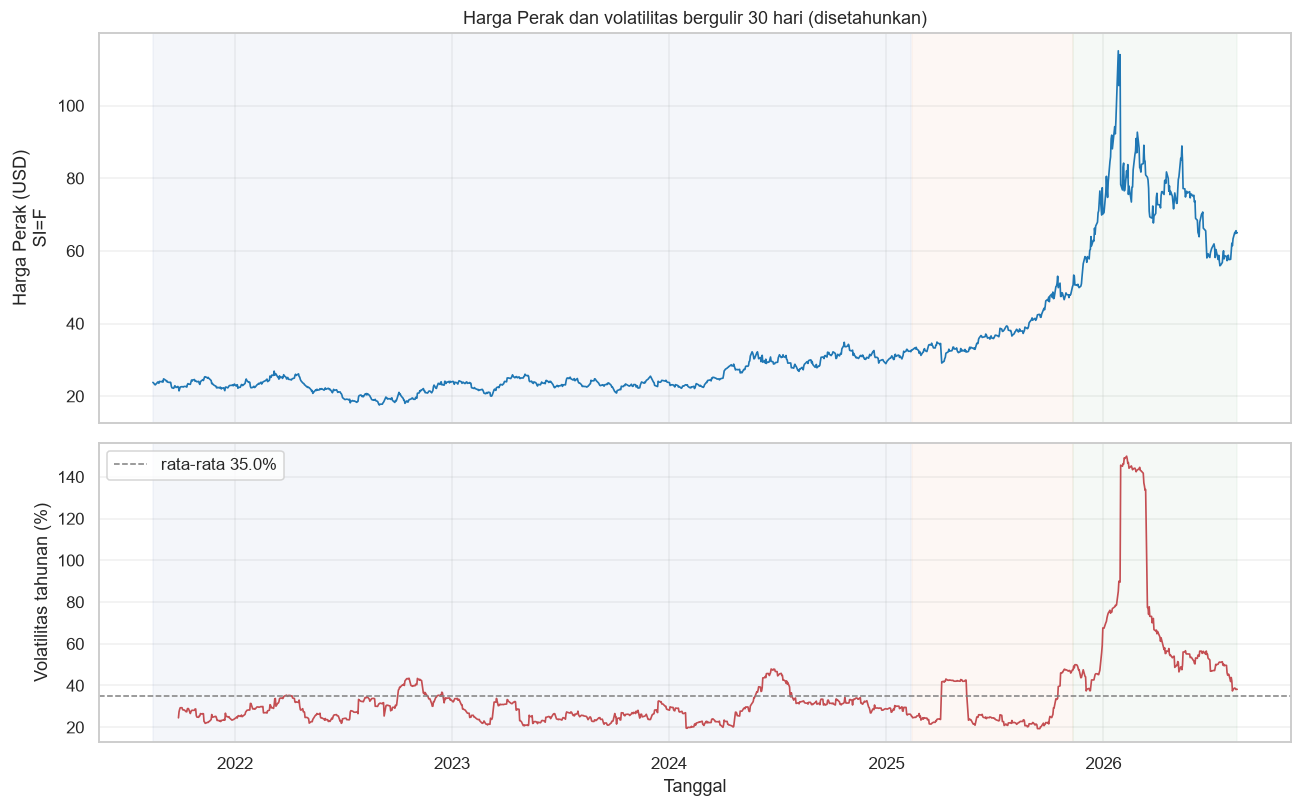

Volatilitas tahunan Perak:
rata-rata (%)    34.9900
minimum (%)      19.3200
maksimum (%)    149.9000
terakhir (%)     38.1600

Puncak volatilitas pada 2026-02-09
Tersimpan: D:\project-skripsi\results\figures\eda_volatility.png


In [11]:
silver_returns = log_returns[TARGET_COL]
rolling_volatility = silver_returns.rolling(VOLATILITY_WINDOW).std()
annualized_volatility = rolling_volatility * np.sqrt(TRADING_DAYS_PER_YEAR)

fig, axes = plt.subplots(2, 1, figsize=(12, 7.5), sharex=True,
                         gridspec_kw={"height_ratios": [1.3, 1]})

axes[0].plot(df.index, df[TARGET_COL], color=PALETTE[TARGET_COL], linewidth=1.1)
axes[0].set_ylabel(f"Harga Perak (USD)\n{TICKERS[TARGET_COL]}")
axes[0].set_title(
    f"Harga Perak dan volatilitas bergulir {VOLATILITY_WINDOW} hari (disetahunkan)"
)

axes[1].plot(annualized_volatility.index, annualized_volatility * 100,
             color="#c44e52", linewidth=1.1)
axes[1].axhline(
    annualized_volatility.mean() * 100,
    color="gray",
    linestyle="--",
    linewidth=1.0,
    label=f"rata-rata {annualized_volatility.mean() * 100:.1f}%",
)
axes[1].set_ylabel("Volatilitas tahunan (%)")
axes[1].set_xlabel("Tanggal")
axes[1].legend(loc="upper left")

for ax in axes:
    for name, color in (("train", "#4c72b0"), ("val", "#dd8452"), ("test", "#55a868")):
        start, end = SPLIT_BOUNDS[name]
        ax.axvspan(start, end, color=color, alpha=0.06)
    ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_volatility.png")
plt.show()

volatility_summary = pd.Series(
    {
        "rata-rata (%)": annualized_volatility.mean() * 100,
        "minimum (%)": annualized_volatility.min() * 100,
        "maksimum (%)": annualized_volatility.max() * 100,
        "terakhir (%)": annualized_volatility.iloc[-1] * 100,
    }
)
print("Volatilitas tahunan Perak:")
print(volatility_summary.round(2).to_string())
print(f"\nPuncak volatilitas pada {annualized_volatility.idxmax().date()}")
print("Tersimpan:", FIGURES_DIR / "eda_volatility.png")

## 8. Dampak penyelarasan tanggal terhadap jumlah baris

Seluruh angka diambil dari `data_quality_report.json` yang dihasilkan `src/preprocessing.py` — tidak dihitung ulang di notebook.

In [12]:
dropped = report["rows_dropped"]
n_union = dropped["n_union_dates"]

d1_table = pd.DataFrame(
    [
        {
            "tahap": "Union tanggal (outer join ketiga seri)",
            "jumlah baris": n_union,
            "% dari union": 100.0,
        },
        {
            "tahap": "Dibuang: target hasil forward fill",
            "jumlah baris": dropped["dropped_target_ffilled"],
            "% dari union": dropped["dropped_target_ffilled"] / n_union * 100,
        },
        {
            "tahap": "Dibuang: NaN tersisa di awal periode",
            "jumlah baris": dropped["dropped_leading_nan"],
            "% dari union": dropped["dropped_leading_nan"] / n_union * 100,
        },
        {
            "tahap": "Total dibuang",
            "jumlah baris": dropped["n_total_dropped"],
            "% dari union": dropped["n_total_dropped"] / n_union * 100,
        },
        {
            "tahap": "Baris akhir yang dipakai",
            "jumlah baris": dropped["n_final"],
            "% dari union": dropped["n_final"] / n_union * 100,
        },
    ]
)
d1_table["% dari union"] = d1_table["% dari union"].round(3)
d1_table

,tahap,jumlah baris,% dari union
0,Union tanggal (outer join ketiga seri),1258,100.0000
1,Dibuang: target hasil forward fill,1,0.0790
2,Dibuang: NaN tersisa di awal periode,0,0.0000
3,Total dibuang,1,0.0790
4,Baris akhir yang dipakai,1257,99.9210


In [13]:
n_final = dropped["n_final"]
ffill_final = report["ffill_counts"]
ffill_before = report.get("ffill_counts_before_drop", {})

ffill_rows = []
for flag_column, count_final in ffill_final.items():
    count_before = ffill_before.get(flag_column, count_final)
    ffill_rows.append(
        {
            "kolom flag": flag_column,
            "ter-ffill sebelum pembuangan": count_before,
            "ter-ffill bertahan di data akhir": count_final,
            "% dari data akhir": round(count_final / n_final * 100, 4),
        }
    )

ffill_table = pd.DataFrame(ffill_rows).set_index("kolom flag")
display(ffill_table)

# Tanggal persisnya, untuk dikutip di laporan
print("Tanggal kovariat yang nilainya hasil forward fill:")
for flag_column in ffill_final:
    dates = df.index[df[flag_column].astype(bool)]
    listed = ", ".join(f"{d.date()} ({d.day_name()})" for d in dates) if len(dates) else "-"
    print(f"  {flag_column:<14} {listed}")

print(f"\nGap kalender terpanjang: {report['calendar_gap']['max_gap_days']} hari "
      f"({report['calendar_gap']['gap_from']} -> {report['calendar_gap']['gap_to']})")
print(f"Pemeriksaan kualitas lolos: {report['passed']}")

,ter-ffill sebelum pembuangan,ter-ffill bertahan di data akhir,% dari data akhir
kolom flag,,,
gold_ffilled,1,0,0.0000
dxy_ffilled,1,1,0.0796


Tanggal kovariat yang nilainya hasil forward fill:
  gold_ffilled   -
  dxy_ffilled    2025-07-04 (Friday)

Gap kalender terpanjang: 4 hari (2021-09-03 -> 2021-09-07)
Pemeriksaan kualitas lolos: True


## 9. Deskripsi Data — ringkasan untuk laporan

Data penelitian mencakup **1.257 hari perdagangan** pada periode **16 Agustus 2021 sampai 14 Agustus 2026**, terdiri atas harga penutupan harian Perak (`SI=F`) sebagai variabel target serta Emas (`GC=F`) dan Dollar Index (`DX-Y.NYB`) sebagai variabel kovariat. Ketiga seri memiliki karakteristik dispersi yang sangat berbeda: harga Perak bergerak dari 17,55 hingga 115,08 USD dengan koefisien variasi 0,529 dan kemencengan positif 1,87, harga Emas bergerak dari 1.623,30 hingga 5.318,40 USD dengan koefisien variasi 0,377, sedangkan Dollar Index relatif stabil pada rentang 92,04–114,11 dengan koefisien variasi hanya 0,041 dan distribusi yang nyaris simetris. Apabila ketiga seri dinormalisasi pada basis 100 di awal periode, Perak menutup periode pada indeks 273,29 dan Emas pada 245,14 — keduanya menunjukkan tren naik yang kuat dan searah — sementara Dollar Index hanya bergerak ke 107,60, yang mengindikasikan bahwa dinamika Perak dan Emas jauh lebih dominan dipengaruhi faktor bersama dibandingkan pergerakan dolar. Distribusi log-return harian ketiga seri menolak hipotesis normalitas pada uji Jarque-Bera (seluruhnya *p* < 0,001), dengan Perak menunjukkan ekor paling tebal (*excess kurtosis* 40,42 dan kemencengan −2,63) serta volatilitas tahunan bergulir 30 hari yang berkisar 19,32%–149,90% dengan rata-rata 34,99% — bukti bahwa peramalan titik saja tidak memadai dan pendekatan probabilistik yang mengukur ketidakpastian menjadi relevan. Uji stasioneritas pada data latih menegaskan bahwa ketiga seri **tidak stasioner pada level harga** namun **stasioner setelah ditransformasi menjadi log-return** (ADF dan KPSS sepakat pada keenam pengujian), sehingga Mutual Information perlu dilaporkan dalam dua varian: pada level harga dan pada log-return.

---

### Tabel rujukan angka

| Karakteristik | Perak (`SI=F`) | Emas (`GC=F`) | DXY (`DX-Y.NYB`) |
|---|---|---|---|
| Jumlah observasi | 1.257 | 1.257 | 1.257 |
| Rata-rata | 33,700 | 2.618,294 | 101,964 |
| Simpangan baku | 17,823 | 986,365 | 4,191 |
| Minimum | 17,551 | 1.623,300 | 92,040 |
| Maksimum | 115,080 | 5.318,400 | 114,110 |
| Kemencengan (level) | 1,867 | 1,072 | 0,051 |
| *Excess kurtosis* (level) | 2,712 | −0,134 | −0,216 |
| Koefisien variasi | 0,529 | 0,377 | 0,041 |
| Indeks akhir (basis 100) | 273,29 | 245,14 | 107,60 |
| Kemencengan (log-return) | −2,634 | −1,124 | −0,363 |
| *Excess kurtosis* (log-return) | 40,420 | 10,660 | 1,634 |
| Jarque-Bera (*p*) | < 0,001 | < 0,001 | < 0,001 |
| ADF level (*p*) | 0,849 | 0,995 | 0,222 |
| ADF log-return (*p*) | < 0,001 | < 0,001 | < 0,001 |
| KPSS level (*p*) | ≤ 0,010 | ≤ 0,010 | ≤ 0,010 |
| KPSS log-return (*p*) | ≥ 0,100 | ≥ 0,100 | ≥ 0,100 |

**Pembagian data:** latih 879 baris (69,93%; 2021-08-16 s/d 2025-02-12), validasi 188 baris (14,96%; 2025-02-13 s/d 2025-11-10), uji 190 baris (15,12%; 2025-11-11 s/d 2026-08-14).

**Dampak penyelarasan tanggal:** dari 1.258 tanggal hasil *outer join*, 1 baris (0,079%) dibuang karena nilai `silver_close`-nya merupakan hasil *forward fill*, yaitu 26 Mei 2025 (Memorial Day, bursa berjangka CME tutup sementara ICE tetap menguotasi DXY). Tidak ada baris yang dibuang karena NaN di awal periode, sehingga 1.257 baris (99,921%) dipertahankan. Nilai kovariat hasil *forward fill* yang bertahan di data akhir hanya 1 dari 1.257 baris (0,080%), yakni `dxy_close` pada 4 Juli 2025 (Independence Day), sedangkan `gold_close` tidak menyisakan satu pun nilai hasil *forward fill*. Jarak kalender terpanjang antar dua hari perdagangan berurutan adalah 4 hari (3–7 September 2021, Labor Day).

**Catatan metodologis.** Nilai *p* pada KPSS dilaporkan sebagai batas tabel (0,010 dan 0,100) karena statistik ujinya berada di luar rentang tabel kritis `statsmodels`; interpretasinya tidak berubah. Uji stasioneritas sengaja dihitung hanya pada data latih agar tidak terjadi kebocoran informasi dari data validasi maupun data uji ke dalam keputusan metodologis, sedangkan statistik deskriptif dan plot pada bagian 2–4 memakai seluruh periode karena sifatnya murni pelaporan.